## Regresja logistyczna

In [10]:
library(ISLR)

In [11]:
names(Smarket)
dim(Smarket)
head(Smarket)

[1] "Year"      "Lag1"      "Lag2"      "Lag3"      "Lag4"      "Lag5"     
[7] "Volume"    "Today"     "Direction"

[1] 1250    9

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
2,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
3,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
4,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
5,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up
6,2001,0.213,0.614,-0.623,1.032,0.959,1.3491,1.392,Up


In [12]:
# Czy próbki mają poprawne etykiety?
all(
    (Smarket$Today >= 0 & Smarket$Direction == "Up")
    |
    (Smarket$Today < 0 & Smarket$Direction == "Down")
)

[1] TRUE

In [13]:
cor(Smarket[-9])

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.00000000,0.029699649,0.030596422,0.033194581,0.035688718,0.029787995,0.53900647,0.030095229
Lag1,0.02969965,1.000000000,-0.026294328,-0.010803402,-0.002985911,-0.005674606,0.04090991,-0.026155045
Lag2,0.03059642,-0.026294328,1.000000000,-0.025896670,-0.010853533,-0.003557949,-0.04338321,-0.010250033
Lag3,0.03319458,-0.010803402,-0.025896670,1.000000000,-0.024051036,-0.018808338,-0.04182369,-0.002447647
Lag4,0.03568872,-0.002985911,-0.010853533,-0.024051036,1.000000000,-0.027083641,-0.04841425,-0.006899527
Lag5,0.02978799,-0.005674606,-0.003557949,-0.018808338,-0.027083641,1.000000000,-0.02200231,-0.034860083
Volume,0.53900647,0.040909908,-0.043383215,-0.041823686,-0.048414246,-0.022002315,1.00000000,0.014591823
Today,0.03009523,-0.026155045,-0.010250033,-0.002447647,-0.006899527,-0.034860083,0.01459182,1.000000000


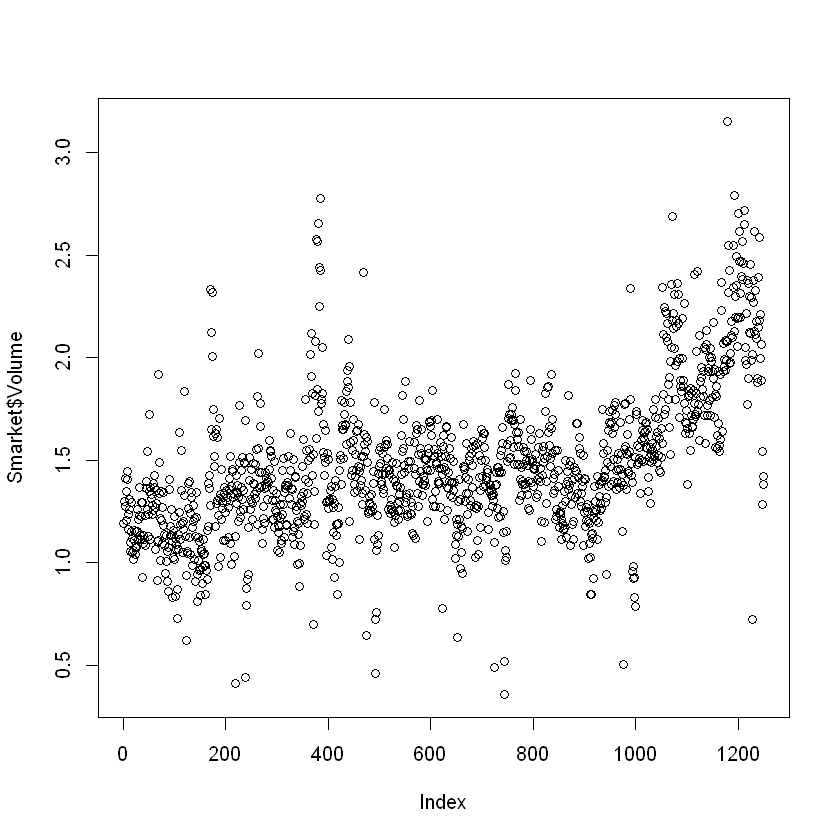

In [14]:
plot(Smarket$Volume)

In [15]:
dir_logistic <- list()
dir_logistic$fit <- glm(Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume, family = binomial, data = Smarket)
summary(dir_logistic$fit)


Call:
glm(formula = Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + 
    Volume, family = binomial, data = Smarket)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)
(Intercept) -0.126000   0.240736  -0.523    0.601
Lag1        -0.073074   0.050167  -1.457    0.145
Lag2        -0.042301   0.050086  -0.845    0.398
Lag3         0.011085   0.049939   0.222    0.824
Lag4         0.009359   0.049974   0.187    0.851
Lag5         0.010313   0.049511   0.208    0.835
Volume       0.135441   0.158360   0.855    0.392

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1731.2  on 1249  degrees of freedom
Residual deviance: 1727.6  on 1243  degrees of freedom
AIC: 1741.6

Number of Fisher Scoring iterations: 3


Wagi w wytrenowanym modelu sa bardzo małe, co oznacza, że nie są istotne. Mamy też duże wartości zmiennej p, więc nie ma podstaw do odrzucenia hipotezy H0 - zmienna nie wpływa znacząco na wynik.

In [16]:
dir_logistic$probs <- predict(dir_logistic$fit, type = "response")
head(dir_logistic$probs)

1         2         3         4         5         6 
0.5070841 0.4814679 0.4811388 0.5152224 0.5107812 0.5069565

In [17]:
contrasts(Smarket$Direction)

,Up
Down,0
Up,1


In [18]:
dir_logistic$predicted <- ifelse(dir_logistic$probs > 0.5, "Up", "Down")

In [19]:
dir_logistic$cm <- table(dir_logistic$predicted, Smarket$Direction)
dir_logistic$cm

      
       Down  Up
  Down  145 141
  Up    457 507

In [20]:
(dir_logistic$cm[1, 2] + dir_logistic$cm[2, 1]) / sum(dir_logistic$cm)
mean(dir_logistic$predicted != Smarket$Direction)

[1] 0.4784

[1] 0.4784